In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.cluster import KMeans
import os
import json
import random
from tqdm import tqdm
import igl
from meshplot import plot

In [2]:
from src.fatemarkers import FateMarkers

In [4]:
path = 'Data/20260224/'


with open(f"{path}/config.json", 'r') as f:
    cfg = json.load(f)
timepoints  = cfg['timepoints']
zarr_names  = cfg['zarr_names']
wells       = cfg['wells']
rounds      = cfg['rounds']
times_dic   = cfg['times_dic']

In [20]:
def find_times(area):
    final_time = np.sqrt(area)
    return np.exp(2 * np.linspace(0, np.log(final_time), 20))

def load(save_path):
    m = FateMarkers()
    m.load_results(save_path)

    _, _, _, _, new_indices = igl.decimate(m.v, m.f, 200)
    ts = find_times(m.area)
    eigvecs = m.eigvecs * np.sqrt(m.area)
    hks = np.array([
        np.einsum('i, ji->j', np.exp(-m.eigvals * t), eigvecs[new_indices, :] ** 2)
        for t in ts
    ]).T

    frac = m.compute_recon_quality()
    c = complexity(m)
    return hks, frac, c, m.area

def complexity(m, threshold=0.015):
    # max SH degree (lmax) at which recon error first drops below threshold;
    # lmax scale (0 = single degree-0 mode), matching compute_master_npz l_cross
    for l in range(1, m.lmax + 1):
        if m.compute_recon_quality(lmax=l) < threshold:
            return l - 1
    return m.lmax - 1

In [5]:
hkss        = []
times       = []
fracs       = []
ids         = []
complexities = []
areas       = []

for timepoint in timepoints:
    zarr_name  = zarr_names[timepoint]
    round_name = rounds[timepoint]
    for well_name in wells[timepoint]:
        file_path = f"{path}/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels, desc=f"{timepoint} {well_name}"):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                try:
                    hks, frac, c, area = load(save_path)
                    hkss.append(hks)
                    times.append(timepoint[3:])
                    fracs.append(frac)
                    ids.append(f"{timepoint}_{well_name}_{label}")
                    complexities.append(c)
                    areas.append(area)
                except Exception as e:
                    print(f"Failed {save_path}: {e}")

day4p5-more C06: 100%|██████████| 132/132 [00:20<00:00,  6.58it/s]


In [58]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

recon_indices = np.where(recon_mask)[0]

ids_array          = np.array(ids)
filtered_ids_array = ids_array[recon_mask]
excluded_ids       = np.setdiff1d(ids_array, filtered_ids_array)
print(f"IDs excluded by filtering: {len(excluded_ids)} out of {len(ids)} total")

filtered_complexities = np.array(complexities)[recon_mask]
filtered_hkss         = [hkss[i] for i in recon_indices]
filtered_times        = np.array(times)[recon_mask]
filtered_ids          = ids_array[recon_mask]
filtered_areas        = np.array(areas)[recon_mask]

IDs excluded by filtering: 171 out of 3402 total


In [59]:
print(f"Organoids loaded: {len(ids)}")

Organoids loaded: 3402


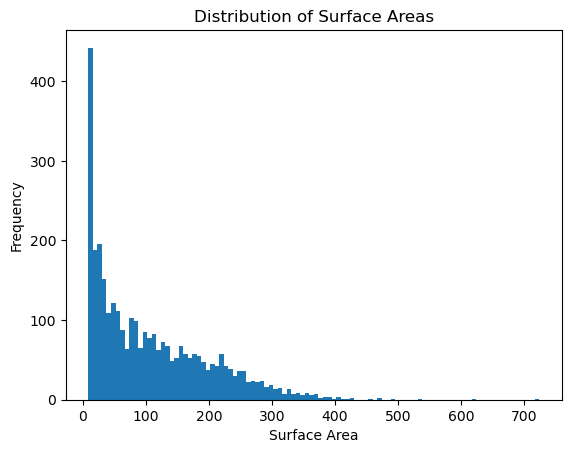

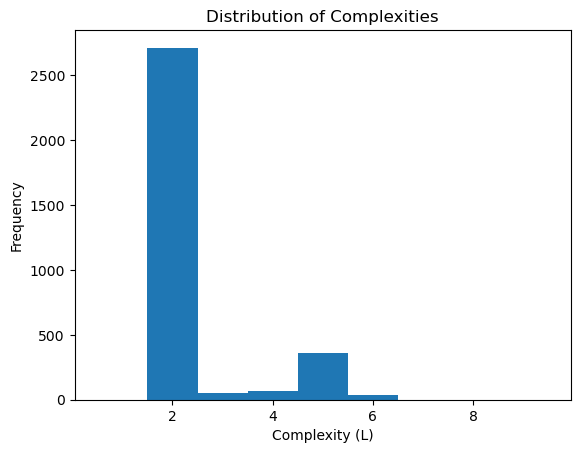

In [60]:
plt.hist(filtered_areas, bins=100)
plt.xlabel('Surface Area')
plt.ylabel('Frequency')
plt.title('Distribution of Surface Areas')
plt.show()

plt.hist(filtered_complexities, bins=np.arange(0.5, 10.5, 1))
plt.xlabel('Complexity (L)')
plt.ylabel('Frequency')
plt.title('Distribution of Complexities')
plt.show()

In [61]:
# draw evenly from complexities
complexity_intervals = [(0, 5.3), (5.3, np.inf)]
no_per_group = [np.sum((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1])) for interval in complexity_intervals]
samples_per_group = int(np.min(no_per_group))

selected_indices = []
for interval in complexity_intervals:
    group_indices = np.where((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1]))[0]
    selected_indices.extend(np.random.choice(group_indices, size=samples_per_group, replace=False))

filtered_times = filtered_times[selected_indices]
filtered_ids = filtered_ids[selected_indices]

In [62]:
# rescale hks by the sum over a single timepoint across one organoid 

def normalise(hks): 
    mean_rm = hks/np.mean(hks, axis=0, keepdims=True) - 1 
    return (mean_rm)

normalised_filtered_hks = [normalise(filtered_hkss[i]) for i in selected_indices]

In [63]:
# Apply indices to filter hkss list
collected_hks = np.concatenate(normalised_filtered_hks)
print(collected_hks.shape)

np.savez('sim/bof_raw_value_variable_time.npz', 
         filtered_ids=filtered_ids,
         filtered_times=filtered_times,
         filtered_hks=collected_hks, 
         hks_per_organoid = [len(hkss) for hkss in filtered_hkss]
)

(105464, 20)


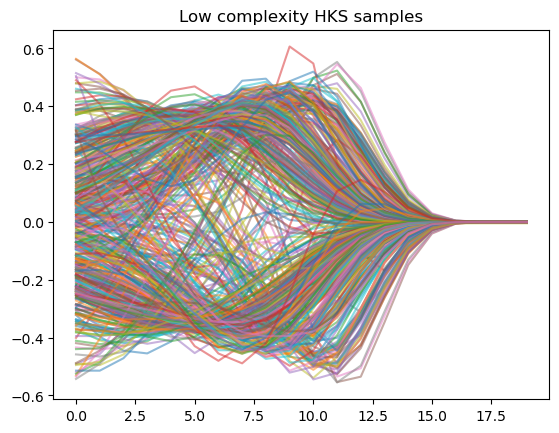

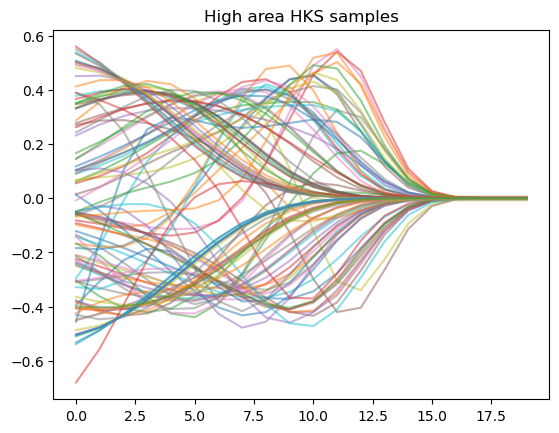

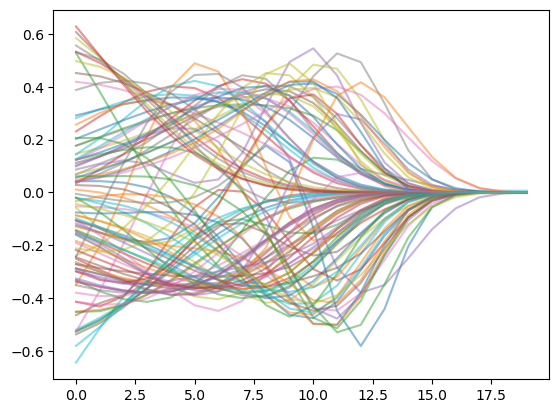

In [64]:
from sklearn.preprocessing import StandardScaler, Normalizer
scaler = Normalizer()
rescaled_hks = scaler.fit_transform(collected_hks)


low_complexity_indices = np.where(filtered_complexities[selected_indices] <= 1)[0]

for i in low_complexity_indices: 
    plt.plot(rescaled_hks[i], alpha=0.5)
plt.title('Low complexity HKS samples')
plt.show() 

high_area_indices = np.where(filtered_areas[selected_indices] >= 300)[0]

for i in high_area_indices: 
    plt.plot(rescaled_hks[i], alpha=0.5)  
plt.title('High area HKS samples')
plt.show()  


import random



random_indices = [random.randint(0, len(rescaled_hks)-1) for _ in range(100)]

for i in random_indices: 
    plt.plot(rescaled_hks[i], alpha=0.5)
plt.show() 

In [49]:
data = np.load('sim/bof_raw_value_variable_time.npz')
filtered_times = data['filtered_times']
filtered_ids = data['filtered_ids']
collected_hks = data['filtered_hks']

In [50]:
curvature_mask = np.abs((rescaled_hks[:, 0] - np.mean(rescaled_hks[:, 0]))/np.std(rescaled_hks[:, 0])) < 4   # select points with curvature feature within [-2, 2]
filtered_rescaled_hks = rescaled_hks[curvature_mask]

In [65]:
from sklearn.cluster import KMeans, HDBSCAN, AgglomerativeClustering
from sklearn.manifold import MDS, TSNE 
from sklearn.decomposition import PCA

dim_reducer = PCA(n_components=4)
hks_2d = dim_reducer.fit_transform(filtered_rescaled_hks)

In [66]:
from sklearn.cluster import KMeans
cluster = KMeans(n_clusters=8, random_state=42)
cluster.fit(filtered_rescaled_hks)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


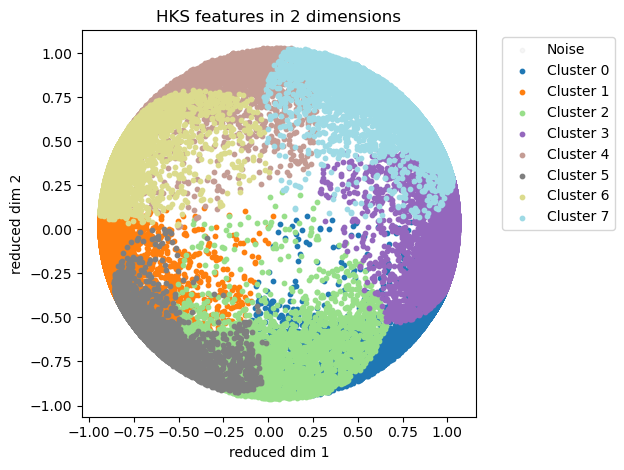

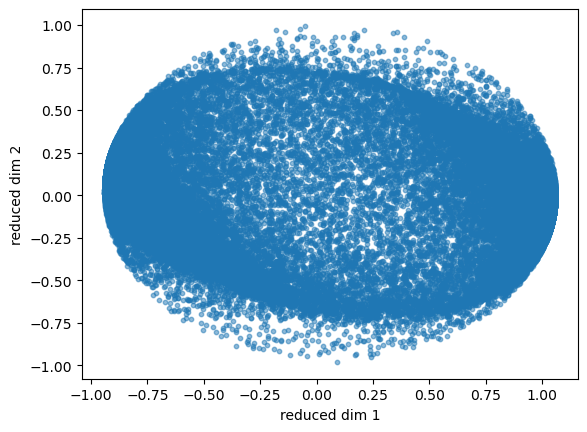

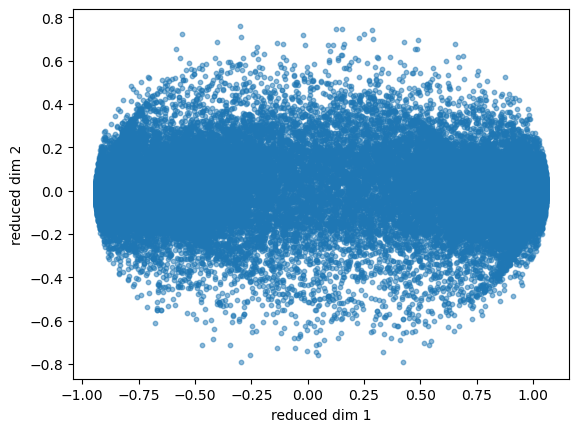

In [68]:
import matplotlib.cm as cm
colors = cm.tab20(np.linspace(0, 1, len(np.unique(cluster.labels_))))
plt.scatter(hks_2d[cluster.labels_==-1, 0], hks_2d[cluster.labels_==-1, 1], 
            s=10, label='Noise', alpha=0.2, c='lightgrey')
for i in range(0, cluster.labels_.max() + 1):
    plt.scatter(hks_2d[cluster.labels_==i, 0], hks_2d[cluster.labels_==i, 1], 
                s=10, label=f'Cluster {i}', alpha=1, c=[colors[i]])
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.title('HKS features in 2 dimensions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.scatter(hks_2d[:, 0], hks_2d[:, 2], s=10, alpha=0.5)
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')     
plt.show() 

plt.scatter(hks_2d[:, 0], hks_2d[:, 3], s=10, alpha=0.5)
plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')     
plt.show() 

In [1]:
# plot the center of each cluster
import random
random_indices = [random.randint(0, len(collected_hks)-1) for _ in range(100)]

rescaled_ts = np.exp(2*np.linspace(0, np.log(4), 20))
for i in random_indices: 
    plt.plot(rescaled_ts, rescaled_hks[i], color='pink', alpha=0.6)

cluster_centers = [] 
colors = plt.cm.tab20(np.linspace(0, 1, cluster.labels_.max() + 1))
for i in range(cluster.labels_.max() + 1):
    center = filtered_rescaled_hks[cluster.labels_==i].mean(axis=0)
    cluster_centers.append(center)  
    plt.plot(rescaled_ts, center, '-', color=colors[i], label=f'Cluster {i} center')
# plt.ylim([0, 0.08])
plt.xscale('log')
plt.xlabel('HKS time')
plt.ylabel('HKS value')
plt.title('Cluster Centers')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NameError: name 'collected_hks' is not defined

In [18]:
cluster_id = cluster.labels_

# compute distance to the nearest cluster center 
dist = np.zeros(filtered_rescaled_hks.shape[0])
for i in range(cluster.labels_.max() + 1):
    m = (cluster_id == i)
    center = cluster_centers[i].reshape(1,-1)
    d = np.linalg.norm(filtered_rescaled_hks[m] - center, axis=1)
    dist[m] = d

sigma = np.sqrt(np.mean(dist**2))
print("Sigma:", sigma)

vocab = np.array(cluster_centers)

Sigma: 0.31217376799359053


In [165]:
np.savez('sim/vocab_variable_time.npz', vocab=vocab, scaler=scaler, sigma=sigma)

In [ ]:
# Alternative vocab: instead of KMeans bag-of-features, use the first three
# PCA components as the "vocabulary". Each vertex is then encoded by its
# projection (coefficients) onto these components rather than a soft assignment
# to cluster centres. Fit on the same scaler-normalised, curvature-masked HKS.
pca_vocab = PCA(n_components=3).fit(filtered_rescaled_hks)
print('PCA vocab explained variance ratio:', pca_vocab.explained_variance_ratio_)

np.savez('sim/vocab_pca_variable_time.npz',
         components=pca_vocab.components_,
         mean=pca_vocab.mean_,
         scaler=scaler)
print('Saved sim/vocab_pca_variable_time.npz  components', pca_vocab.components_.shape)

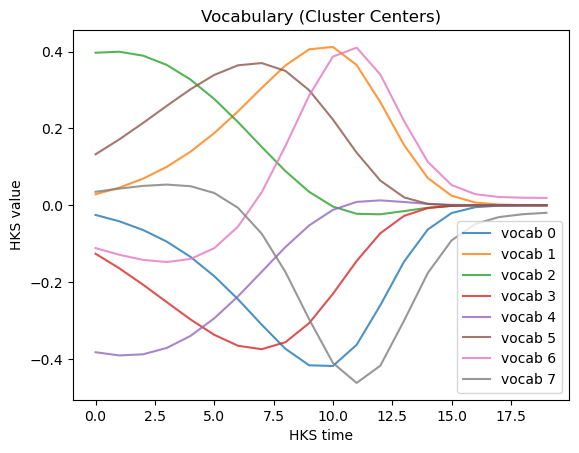

In [11]:
res = np.load('sim/vocab_variable_time.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']


for i, v in enumerate(vocab):
    plt.plot(v, alpha=0.8, label=f'vocab {i}')
plt.xlabel('HKS time')
plt.ylabel('HKS value')
plt.title('Vocabulary (Cluster Centers)')
plt.legend()
plt.show()